In [ ]:
!pwd

OpenCV 附帶的- 數據集
OCR - Digits dataset: digits.png 

5000 pictures  
500 pictures/digit

Each picture is 20×20 gray scale, background is black 


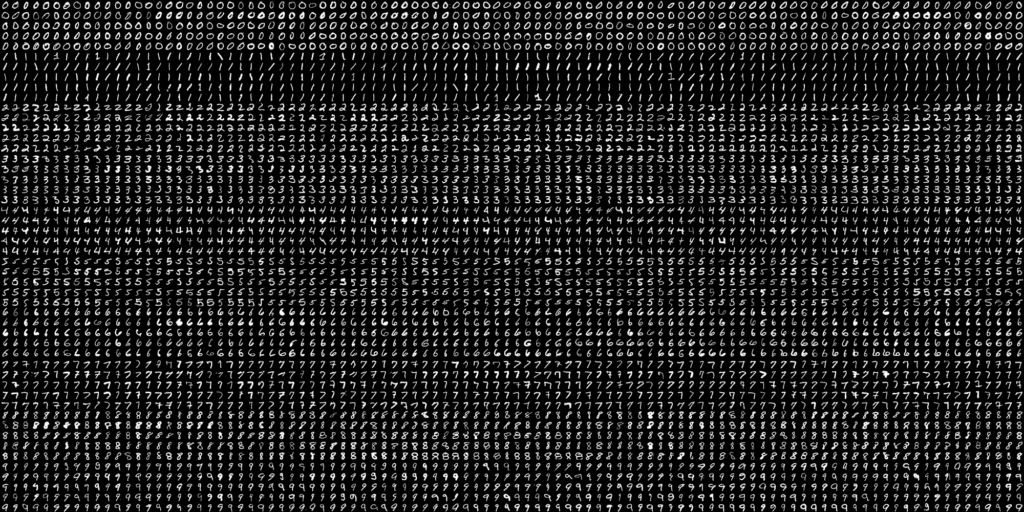

Preprocessing: deskew

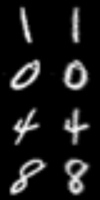

class Moments { public: ...... //"spatial moments" double m00, m10, m01, m20, m11, m02, m30, m21, m12, m03; // "central moment" double mu20, mu11, mu02, mu30, mu21, mu12, mu03; // normalized moment double nu20, nu11, nu02, nu30, nu21, nu12, nu03; }

>spatial moments 與像素大小及位置有關
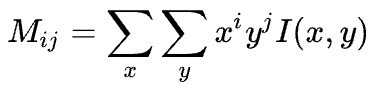


>central moments 與質心相關的特徵
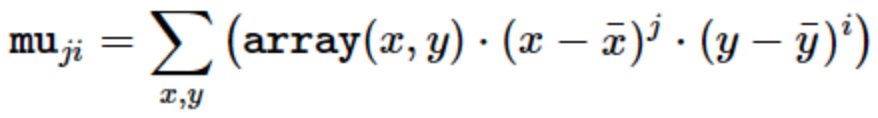


>normalized central moments
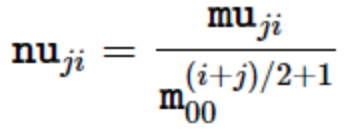


>Hu Moments: cv2.HuMoments(const Moments& m, OutputArray hu) 不變矩 invariants with respect to translation, scale, and rotation
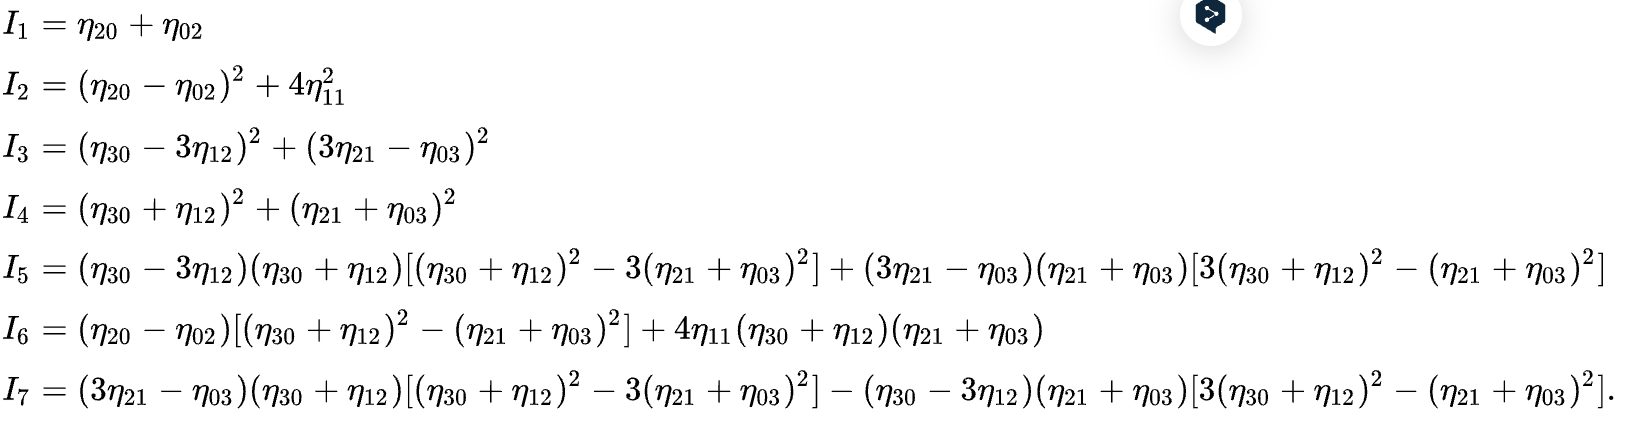

skewness:
It is given by the ratio of two central moments (mu11 / mu02). 

The calculated skewness can be used to calculate an affine transformation for image correction


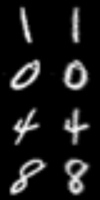


In [1]:
from pathlib import Path

root = Path.cwd()
candidate = root / "data" / "digits.png"
print("CWD =", root)
print("digits.png 存在嗎？", candidate.exists())
print("要找的完整路徑 =", candidate)

CWD = /Users/hjc/venv/CV_Class/L7_S
digits.png 存在嗎？ True
要找的完整路徑 = /Users/hjc/venv/CV_Class/L7_S/data/digits.png


In [3]:
import cv2
import numpy as np

# ---------------------------
# Config
# ---------------------------
SZ = 20                   # 每個數字影像的尺寸 (20x20)
GRID_ROWS = 50            # digits.png 的行數
GRID_COLS = 100           # digits.png 的列數
DISPLAY_SCALE = 2         # 顯示時放大倍數
#FALLBACK_PATH = "data/digits.png"  # 若找不到 samples，改成你的本機路徑

# ---------------------------
# 利用中央矩 deskew
# 參考公式: skew = mu11 / mu02
# 仿射矩陣: [[1, skew, -0.5*SZ*skew],
#            [0,   1 ,  0           ]]
# ---------------------------
def deskew(img, size=SZ):
    m = cv2.moments(img)
    # mu02 太小代表無法穩定估計傾斜，直接回傳原圖
    if abs(m["mu02"]) < 1e-2:
        return img.copy()
    skew = m["mu11"] / m["mu02"]
    M = np.float32([[1, skew, -0.5 * size * skew],
                    [0, 1, 0]])
    # 使用 WARP_INVERSE_MAP 讓仿射矩陣以逆映射方式套用
    deskewed = cv2.warpAffine(
        img, M, (size, size),
        flags=cv2.WARP_INVERSE_MAP | cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_REPLICATE
    )
    return deskewed

# ---------------------------
# 將所有 20x20 影像依原始順序拼回一張大圖
# imgs: list/array of (H,W) uint8 images, 長度應為 GRID_ROWS*GRID_COLS
# ---------------------------
def make_montage(imgs, rows=GRID_ROWS, cols=GRID_COLS, cell_size=SZ):
    assert len(imgs) == rows * cols, "影像數量與網格大小不一致"
    # 先把一維列表轉成 (rows, cols, H, W)
    grid = []
    k = 0
    for r in range(rows):
        row_imgs = []
        for c in range(cols):
            row_imgs.append(imgs[k])
            k += 1
        grid.append(row_imgs)
    # 每一列水平拼接，再把所有列垂直拼接
    row_strips = [np.hstack(row) for row in grid]
    montage = np.vstack(row_strips)
    return montage

def main():
    # 讀取 digits.png
    path = None
    try:
        path = cv2.samples.findFile("data/digits.png", required=False)
    except Exception:
        path = None
    if not path:
        path = FALLBACK_PATH

    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(
            f"找不到 digits.png。請確認 OpenCV samples 是否已安裝，"
            f"或將 FALLBACK_PATH 設為你的檔案路徑。現在的路徑: {path}"
        )

    H, W = img.shape
    assert H % SZ == 0 and W % SZ == 0, "影像尺寸與單格大小不相容"
    rows, cols = H // SZ, W // SZ
    # 若與預設不同，也以實際尺寸為準
    global GRID_ROWS, GRID_COLS
    GRID_ROWS, GRID_COLS = rows, cols

    # 切出每個 20x20 的小影像
    cells = []
    for r in range(rows):
        for c in range(cols):
            cell = img[r*SZ:(r+1)*SZ, c*SZ:(c+1)*SZ]
            cells.append(cell)

    # 對每個 cell 做 deskew（用中央矩）
    deskewed_cells = [deskew(cell) for cell in cells]

    # 拼接成兩張大圖：原始、deskew 後
    montage_before = make_montage(cells, rows, cols, SZ)
    montage_after  = make_montage(deskewed_cells, rows, cols, SZ)

    # 顯示（可視需要放大以便觀看）
    if DISPLAY_SCALE != 1:
        montage_before_disp = cv2.resize(
            montage_before, None, fx=DISPLAY_SCALE, fy=DISPLAY_SCALE, interpolation=cv2.INTER_NEAREST
        )
        montage_after_disp = cv2.resize(
            montage_after, None, fx=DISPLAY_SCALE, fy=DISPLAY_SCALE, interpolation=cv2.INTER_NEAREST
        )
    else:
        montage_before_disp = montage_before
        montage_after_disp = montage_after

    cv2.imshow("All digits - BEFORE deskew", montage_before_disp)
    cv2.imshow("All digits - AFTER deskew (central moments)", montage_after_disp)
    cv2.waitKey(0)
    cv2.destroyAllWindows()
    for i in range(2):
        cv2.waitKey(1)
if __name__ == "__main__":
    main()

2025-10-30 15:42:19.681 python[45701:2802075] The class 'NSSavePanel' overrides the method identifier.  This method is implemented by class 'NSWindow'


KeyboardInterrupt: 

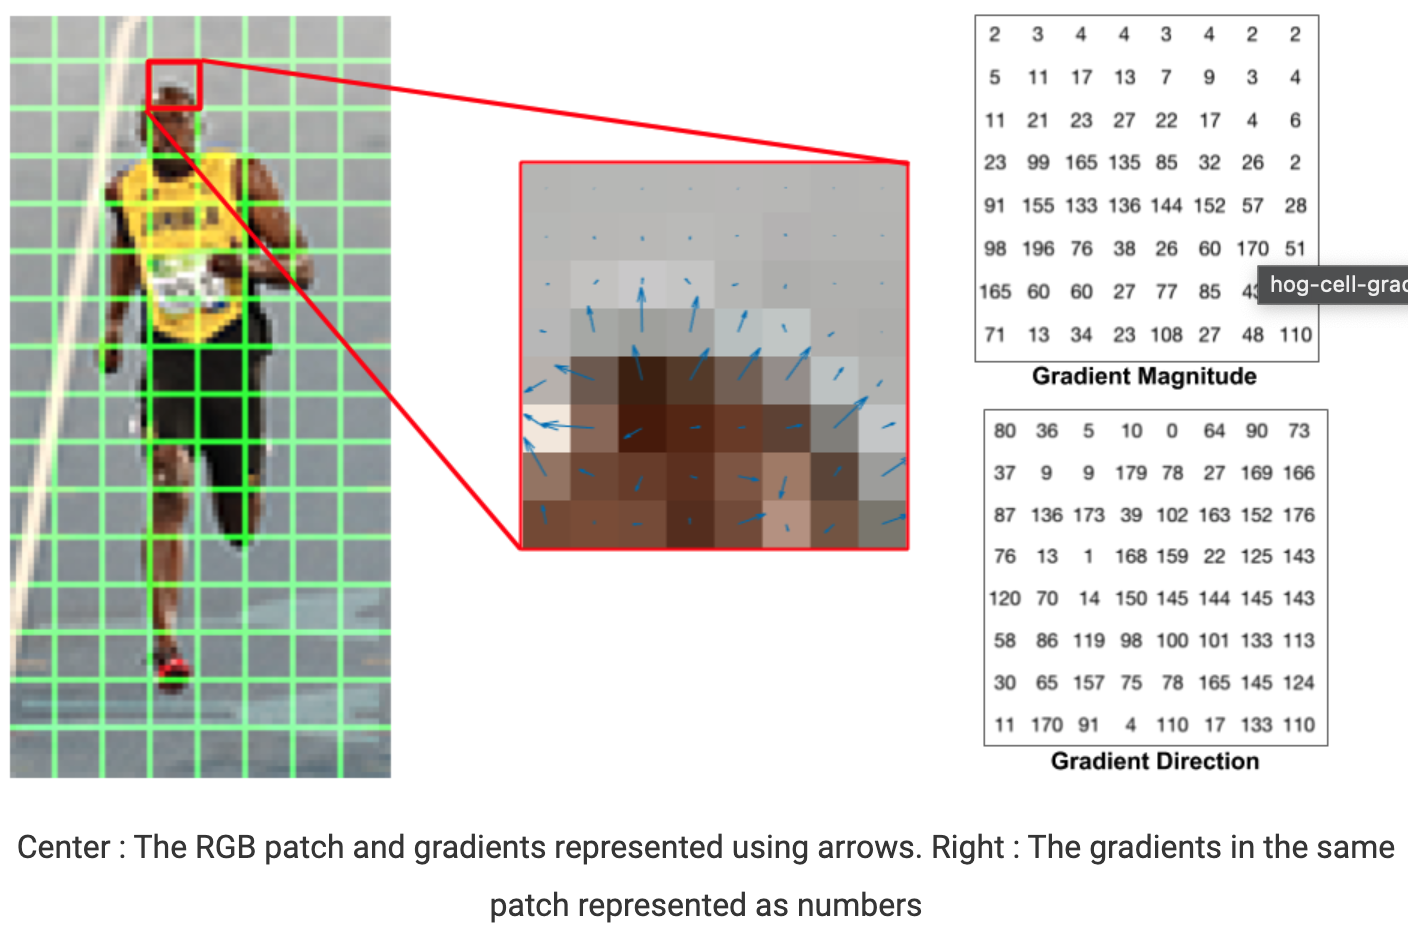

The Histogram of Oriented Gradients (HOG) descriptor is a feature descriptor that converts a grayscale image into a feature vector. The HOG descriptor is used to detect objects in images and is widely used in computer vision and machine learning. The HOG descriptor is calculated by dividing the image into small connected regions called cells, and for the pixels within each cell, a histogram of gradient directions is compiled. The descriptor is the concatenation of these histograms.

To calculate the HOG descriptor, you need to select the following parameters:

Cell size: The size of the cell in pixels.
Block size: The number of cells per block.
Block stride: The number of pixels between adjacent blocks.
Number of orientation bins: The number of bins in the histogram of gradient directions.

cv2.HOGDescriptor(winSize, blockSize, blockStride, cellSize, nbins,
                        derivAperture=1, winSigma=-1, histogramNormType=0,
                        L2HysThreshold=0.2, gammaCorrection=True,
                        nlevels=64, signedGradient=False)

參數           類型.            說明
winSize (width, height) 檢測視窗大小，表示輸入影像的分析區塊大小。行人偵測預設為 (64, 128)。

blockSize   (width, height) block 大小：由多少個 cell 組成的區塊（通常為 2×2 cell，如 (16, 16) 當 cellSize 為 (8,8) 時）。每個 block 會進行歸一化。

blockStride (width, height) block 的滑動步長：block 在影像上移動時，每次滑動多少像素（通常是 cellSize，例如 (8,8)）。

cellSize    (width, height) cell 大小：每個 cell 用來計算方向直方圖的基本單位。常見為 (8,8)。

nbins   int 方向直方圖的桶數：即方向被分成幾個角度區間，常用 9（表示 0°–180° 分 9 個 bin）。

derivAperture   int 用於計算梯度的 Sobel 濾波器 aperture size（通常為 1）。

winSigma    float   高斯平滑參數 σ，用於梯度強度的平滑。若為 -1 表示自動選擇。

histogramNormType   int 歸一化類型（cv2.HOGDescriptor_L2Hys = 0，預設），代表 L2-Hys normalization。

L2HysThreshold  float   L2-Hys 歸一化的截斷閾值（通常為 0.2）。

gammaCorrection bool    是否在計算梯度前進行伽瑪校正（可改善光照差異影響，預設 True）。

nlevels int 用於多尺度偵測時的影像金字塔層數（預設 64）。

signedGradient  bool    是否區分方向正負（False → [0,180°)，True → [0,360°)）。多數情況設為 False。



    >> winSize：參數設置為 20×20
        >> 因為數據集中的數字圖像的大小是 20×20
        >> 為整個圖像計算一個Descriptor

    >> cellSize：數字是 20×20 gray scale
        >> 換句話說，圖像由 20×20 = 400數字表示
        >> 描述符的大小通常遠小於圖像中的像素數
        >> 基於進行分類的重要特徵的尺度來選擇cellSize
        >> 一個非常小的 cellSize會炸掉特徵向量的大小
        >> 一個非常大的cellSize可能無法捕獲相關訊息
        >> 適當應該使用適當的大小 - 選擇了10×10 的 cellSize

    >> blockSize：塊的概念 存在以 解決 亮度變化
        >> 較大的塊大小 使local變化不太重要，
        >> 較小的塊大小 使local的變化影響較大
        >> 通常blockSize 設置為 2 x cellSize
        >> 但在數字分類示例中 - 10×10 的 blockSize- 會是最好的結果

    >> blockStride：blockStride 確定相鄰塊之間的重疊
        >> 並控制對比度標準化程度
        >> blockStride設置 -blockSize的 50％

    >> nbins：nbins設置漸變直方圖中的bin數
        >> HOG論文的作者建議使用值9來捕獲 0 到 180度之間 的漸變
            >> 以 20度為 增量

    >> signed Gradients：
        >> 通常，漸變 gradients可以具有 0 到 360 度 之間的任何方向
        >> 這些梯度被稱為“有符號 signed ”梯度
            >> 而不是“無符號 unsigned ”梯度
        >> 使符號下降並取 0到180度之間的值
        >> 在原始 HOG紙中，無符號梯度用於行人檢測 pedestrian detection
        
    >> defined Coding 計算圖像的 HOG 特徵 HOG features

    >> descriptor = hog.compute(im)
        >> 描述符的大小 - 81×1

支持向量機（SVM）是一種常用的分類演算法。在 n 維空間中，線性 SVM 會使用平面來劃分空間，將不同的類別分布在平面的不同側.

下圖展示了有兩個由紅色和藍色圓點表示的類別。如果將此數據輸入到線性 SVM 中，可以構建分類器，通過查找明確區分這兩個類別。有許多方法可以分離這些數據，SVM 選擇處於任一類的最大距離數據點的那個邊


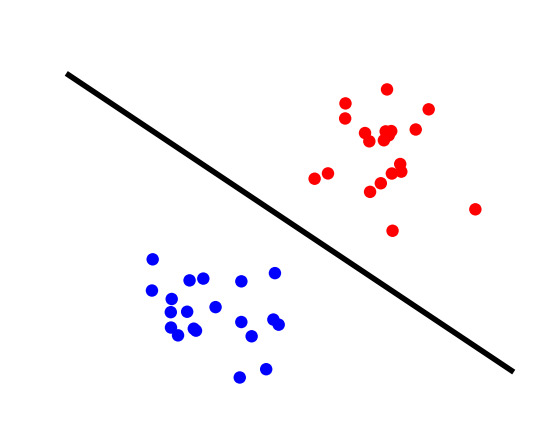

C參數是訓練SVM時需要瞭解的兩個常見參數之一。 真實世界的數據並不像上面顯示的那樣乾淨。 有時，訓練數據可能有帶有錯誤標記的示例，而在其他情況下，一組中的一個示例在外觀上可能與另一個示例太相似。

例如，手寫數位2可能看起來像3。 在下面的動畫中，請注意藍點太靠近紅色簇。 當選擇預設值C = 1時，藍點被錯誤分類。 但是，當選擇C為100時，它被正確分類。

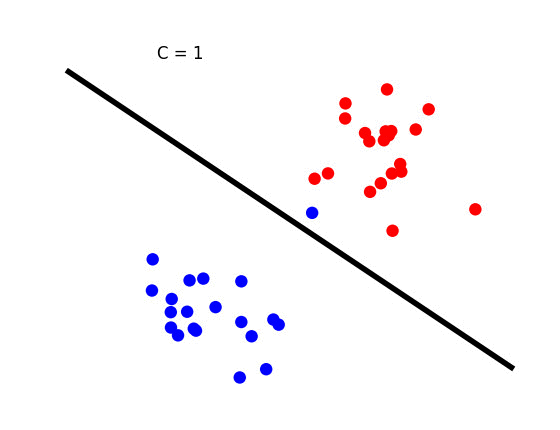

SVM 參數 Gamma：非線性 SVM

>> 分類任務中
   >> 如果包含數據的空間可以使用平面（或2D中的線）進行分區以分隔類稱為線性可分

>> 如果數據不是線性可分的怎麼辦
   >> 下圖範例使用紅色和藍色點的兩個類
>> 這些點不是線性可分的無法在平面上繪製一條線來分隔這兩個類
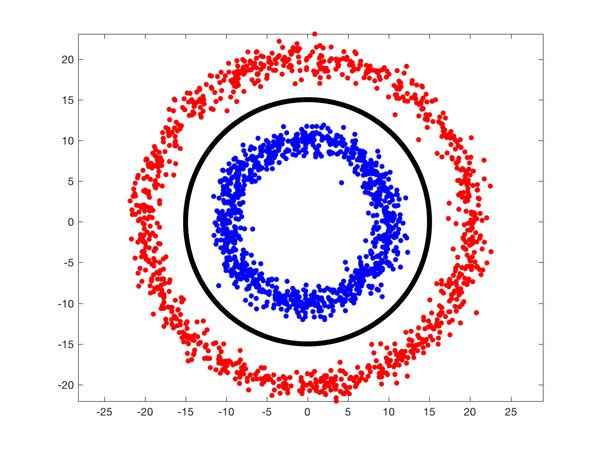

Kernel Trick 的技術
>> 可將非線性可分離數據轉換為線性可分離數據，將2D平面上所有數據點添加第三維

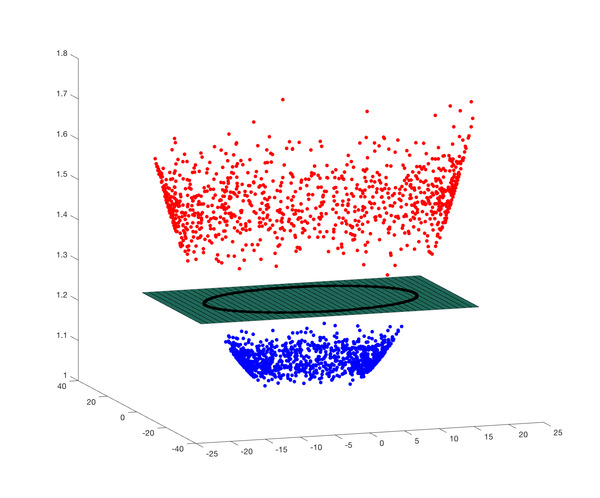

In [4]:
import cv2
import numpy as np

SZ=20
bin_n = 16 # bins 數 目
affine_flags = cv2.WARP_INVERSE_MAP|cv2.INTER_LINEAR

def deskew(img):
    m = cv2.moments(img)
    if abs(m['mu02']) < 1e-2:
        return img.copy()
    skew = m['mu11']/m['mu02']
    M = np.float32([[1, skew, -0.5*SZ*skew], [0, 1, 0]])
    img = cv2.warpAffine(img,M,(SZ, SZ),flags=affine_flags)
    return img

# 使用 OpenCV 內建的 HOGDescriptor
hog_descriptor = cv2.HOGDescriptor(_winSize=(SZ, SZ),
                                    _blockSize=(10, 10),
                                    _blockStride=(10, 10),
                                    _cellSize=(10, 10),
                                    _nbins=bin_n)

def hog(img):
    # 使用 OpenCV 內建函式計算 HOG
    hist = hog_descriptor.compute(img)
    return hist.flatten()
#每個單元格的 HOG descriptor在 X 和 Y 方向 找到每個單元的 Sobel導數
#然後在每個像素處找到它們的大小和梯度方向該梯度量化為16個整數值
#將此圖像分為 四個子方塊對於每個子平方，計算方向的直方圖（16個區間）加權其大小,因此每個子方格都會為您提供一個包含16個值的向量
#四個這樣的向量（四個子方塊一起給出了包含64個值的特徵向量

img = cv2.imread('data/digits.png',0)
# img = cv2.imread('data/digits.png',0)


if img is None:
    raise Exception("we need the digits.png image from samples/data here !")
cells = [np.hsplit(row,100) for row in np.vsplit(img,50)]


# 50% -trainData， 50% -testData 

train_cells = [ i[:50] for i in cells ]
test_cells = [ i[50:] for i in cells]
deskewed = [list(map(deskew,row)) for row in train_cells]
hogdata = [list(map(hog,row)) for row in deskewed]
trainData = np.float32(hogdata).reshape(-1,64)
responses = np.repeat(np.arange(10),250)[:,np.newaxis]
svm = cv2.ml.SVM_create()
svm.setKernel(cv2.ml.SVM_LINEAR)
svm.setType(cv2.ml.SVM_C_SVC)
svm.setC(2.67)
svm.setGamma(5.383)
svm.train(trainData, cv2.ml.ROW_SAMPLE, responses)
svm.save('svm_data.dat')

deskewed = [list(map(deskew,row)) for row in test_cells]
hogdata = [list(map(hog,row)) for row in deskewed]
testData = np.float32(hogdata).reshape(-1,64)
result = svm.predict(testData)[1]
mask = result==responses

correct = np.count_nonzero(mask)
print(correct*100.0/result.size)

93.56


>> 定向梯度 直方圖

>> Histogram of Oriented Gradients(HOG)

In [5]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Load 加載 圖像 灰色 - GrayScale

image = cv2.imread('images/elephant.jpg')
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# 顯示 原始圖像 

cv2.imshow('Input Image - elephant ', image)
cv2.waitKey(0)

# H x W  像素 Pixels

cell_size = (8, 8) 

# H x W  細胞框 Cells
    
block_size = (2, 2) 

# Bins 數量 - Number of Orientation bins

nbins = 9

# OpenCV HOG 描述符 - Descriptor

# WinSize 單元格大小倍數的 圖像大小


hog = cv2.HOGDescriptor(_winSize=(gray.shape[1] // cell_size[1] * cell_size[1],
                                  gray.shape[0] // cell_size[0] * cell_size[0]),
                        _blockSize=(block_size[1] * cell_size[1],
                                    block_size[0] * cell_size[0]),
                        _blockStride=(cell_size[1], cell_size[0]),
                        _cellSize=(cell_size[1], cell_size[0]),
                        _nbins=nbins)

# 創建 HoG_Feats 的 Nnumpy 數組形狀

n_cells = (gray.shape[0] // cell_size[0], gray.shape[1] // cell_size[1])

# 行索 - Index Blocks By Rows 
# HoG_Feats - 包含 每個方向 的梯度幅度 - Gradient Amplitudes



hog_feats = hog.compute(gray).reshape(n_cells[1] - block_size[1] + 1,
                        n_cells[0] - block_size[0] + 1,
                        block_size[0], block_size[1], nbins).transpose((1, 0, 2, 3, 4))  

# Nbin 維度創建= 漸變數組 Gradients Array - 存儲 Gradient Orientations 

gradients = np.zeros((n_cells[0], n_cells[1], nbins))

# 創建 維度數組 - Array Of Dimensions 
cell_count = np.full((n_cells[0], n_cells[1], 1), 0, dtype=int)

# Normalization
for off_y in range(block_size[0]):
    for off_x in range(block_size[1]):
        gradients[off_y:n_cells[0] - block_size[0] + off_y + 1,
                  off_x:n_cells[1] - block_size[1] + off_x + 1] += \
            hog_feats[:, :, off_y, off_x, :]
        cell_count[off_y:n_cells[0] - block_size[0] + off_y + 1,
                   off_x:n_cells[1] - block_size[1] + off_x + 1] += 1

# 平均梯度 - Average Gradients
gradients /= cell_count

# 繪製 HOG
# Angle 角度 是 360 / nbins 方向


color_bins = 5
plt.pcolor(gradients[:, :, color_bins])
plt.gca().invert_yaxis()
plt.gca().set_aspect('equal', adjustable='box')
plt.colorbar()
plt.show()
cv2.destroyAllWindows()
for i in range (1,5): 
    cv2.waitKey(1)

ModuleNotFoundError: No module named 'matplotlib'

### Harris Corner Detection is an algorithm developed in 1998 for corner detection  (http://www.bmva.org/bmvc/1988/avc-88-023.pdf) and works fairly well.
### Harris Corner Detection 是　- 1998年 開發的　用於 角點檢測的 演算法 Algorithm

**cv2.cornerHarris**(input image, block size, ksize, k)
- Input image - 灰度 -　Grayscale　和 Float32 資料類型
- BlockSize - Corner Detection　-　考慮角點檢測的　鄰域大小
- ksize - Aperture 光圈 Parameter - Sobel Derivative used－　Sobel　Derivative　參數
- k - Harris Detector 哈里斯檢測器 自由參數 - Equation
- **Output** – array of corner locations 角落位置  (x,y)

In [6]:
import cv2
import numpy as np

# Load 加載 圖像 灰色 - Grayscale

image = cv2.imread('images/chess.jpg')
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# CornerHarris 函數要求 數組數據 Array Datatype 類型為 - Float32

gray = np.float32(gray)

harris_corners = cv2.cornerHarris(gray, 3, 3, 0.05)

# 擴大角點 Corner Points  Dilation 放大 Enlarge


kernel = np.ones((7,7),np.uint8)
harris_corners = cv2.dilate(harris_corners, kernel, iterations = 2)

# 圖像檢測 的 最佳 的 閾值 Threshold Optimal Value

image[harris_corners > 0.025 * harris_corners.max() ] = [255, 127, 127]

cv2.imshow('Harris Corners', image)
cv2.waitKey(0)
cv2.destroyAllWindows()
# 確保 OSx上的 窗口關閉
for i in range (1,5):
    cv2.waitKey(1)


提升角點檢測 Corner Detection 的 的另一種方法
>> Improved Corner Detection 
        
>> cv2.goodFeaturesToTrack
**cv2.goodFeaturesToTrack**(input image, maxCorners, qualityLevel, minDistance)

- Input Image - 輸入圖像 -  8 位元 或 浮點32位元 單通道圖像 - Single cChannel Image.
- MaxCorners  - Maximum number of corners to return. 返回的最大角數 - 如果角落多於找到的角落，則返回最佳點的角落
- QualityLevel- 表徵圖像角落的最小可接受質量的參數 .  參數值乘 以最佳拐角質量測量值(最小特徵值)


In [7]:
import cv2
import numpy as np

img = cv2.imread('images/chess.jpg')
gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)

# 指定  前 50個 角落  點 - 50 Corners Points

corners = cv2.goodFeaturesToTrack(gray, 100, 0.01, 150)

for corner in corners:
    x, y = corner[0]
    x = int(x)
    y = int(y)
    cv2.rectangle(img,(x-10,y-10),(x+10,y+10),(0,255,0), 2)
    
cv2.imshow("Corners Found", img)
cv2.waitKey(0)
cv2.destroyAllWindows()
for i in range (1,5):
    cv2.waitKey(1)


In [1]:
import cv2
import numpy as np

face_classifier = cv2.CascadeClassifier('Haarcascades/haarcascade_frontalface_default.xml')
eye_classifier = cv2.CascadeClassifier('Haarcascades/haarcascade_eye_tree_eyeglasses.xml')
#https://github.com/opencv/opencv/tree/master/data/haarcascades

def face_detector(img, size=0.5):
    
# 圖像 轉換 Convert  為 灰色 - GrayScale
    
    gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
    faces = face_classifier.detectMultiScale(gray, 1.3, 5)
    if faces is ():
        return img
    
    for (x,y,w,h) in faces:
        x = x - 50
        w = w + 50
        y = y - 50
        h = h + 50
        cv2.rectangle(img,(x,y),(x+w,y+h),(255,0,0),2)
        roi_gray = gray[y:y+h, x:x+w]
        roi_color = img[y:y+h, x:x+w]
        eyes = eye_classifier.detectMultiScale(roi_gray)
        
        for (ex,ey,ew,eh) in eyes:
            cv2.rectangle(roi_color,(ex,ey),(ex+ew,ey+eh),(0,0,255),2) 
            
    return img

cap = cv2.VideoCapture(0)

while True:

    ret, frame = cap.read()
    cv2.imshow('Our Face Extractor', face_detector(frame))
    if cv2.waitKey(20) == 13:        # 13 is the Enter Key
        break
        
cap.release()
cv2.destroyAllWindows()
for i in range (1,5):
    cv2.waitKey(1)

<>:14: SyntaxWarning: "is" with 'tuple' literal. Did you mean "=="?
<>:14: SyntaxWarning: "is" with 'tuple' literal. Did you mean "=="?
/var/folders/8_/tqzlktmj6835m_4ymz7mqkb00000gn/T/ipykernel_45917/2113326971.py:14: SyntaxWarning: "is" with 'tuple' literal. Did you mean "=="?
  if faces is ():
2025-10-30 15:50:09.667 python[45917:2812510] WARNING: AVCaptureDeviceTypeExternal is deprecated for Continuity Cameras. Please use AVCaptureDeviceTypeContinuityCamera and add NSCameraUseContinuityCameraDeviceType to your Info.plist.
2025-10-30 15:50:09.667 python[45917:2812510] WARNING: AVCaptureDeviceTypeExternal is deprecated for Continuity Cameras. Please use AVCaptureDeviceTypeContinuityCamera and add NSCameraUseContinuityCameraDeviceType to your Info.plist.


KeyboardInterrupt: 

In [2]:
import cv2
import time
import numpy as np

# 建立 汽車分類器 - Car Classifier
car_classifier = cv2.CascadeClassifier('Haarcascades/haarcascade_car.xml')

# 啟動 Video apture 啟動視頻 捕獲 - Video File
cap = cv2.VideoCapture('images/cars.avi')


# 視頻 加載 

while cap.isOpened():
    
    time.sleep(.05)
    # 讀 Read 第一 Frame
    
    ret, frame = cap.read()
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
   
   
    
    cars = car_classifier.detectMultiScale(gray, 1.4, 2)
    
    # 提取 識別的 邊界框 Bounding Boxes 
    
    for (x,y,w,h) in cars:
        cv2.rectangle(frame, (x, y), (x+w, y+h), (0, 255, 255), 2)
        cv2.imshow('Cars', frame)

    if cv2.waitKey(1) == 13: # 13 is the Enter Key
        break

cap.release()
cv2.destroyAllWindows()
for i in range (1,5):
    cv2.waitKey(1)


KeyboardInterrupt: 

In [2]:
import cv2
import numpy as np

# Create 創建 身體分類器  - Body Classifier

body_classifier = cv2.CascadeClassifier('Haarcascades/haarcascade_fullbody.xml')

# 啟動 video capture 啟動視頻 捕獲 - video file

cap = cv2.VideoCapture('images/walking.avi')

#  循環一次 視頻 成功加載  - successfully loaded

while cap.isOpened():
    
    # 讀 Read 第一 frame
    
    ret, frame = cap.read()
    frame = cv2.resize(frame, None,fx=0.5, fy=0.5, interpolation = cv2.INTER_LINEAR)

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    
    #  frame 傳遞給 - 身體分類器 - body classifier 
    bodies = body_classifier.detectMultiScale(gray, 1.2, 3)
    
    # 提取邊界框 - Extract bounding boxes 識別的任何物體 - identified
    
    for (x,y,w,h) in bodies:
        cv2.rectangle(frame, (x, y), (x+w, y+h), (0, 255, 255), 2)
        cv2.imshow('Pedestrians', frame)

    if cv2.waitKey(1) == 13: # ESC - 13 is the Enter Key
        break

cap.release()
cv2.destroyAllWindows()
for i in range (1,5):
    cv2.waitKey(1)

error: OpenCV(4.12.0) /Users/runner/miniforge3/conda-bld/libopencv_1756075605565/work/modules/imgproc/src/resize.cpp:4208: error: (-215:Assertion failed) !ssize.empty() in function 'resize'


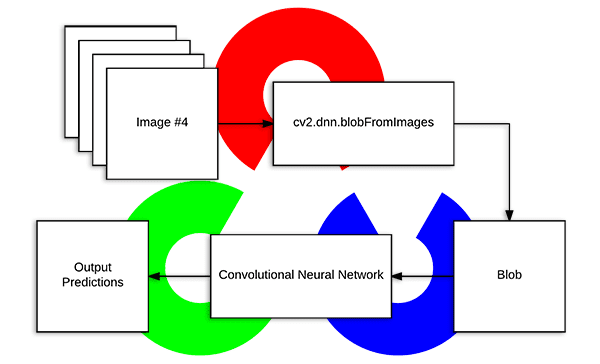

一、cv2.dnn
	•	cv2.dnn 是 OpenCV 中專門處理 深度神經網絡推理（inference） 的模組。 ￼
	•	它並不負責從頭訓練神經網絡（大多不支援訓練新模型），而是用來載入已訓練模型，並在圖片／影像上進行推論（分類、偵測、分割、文字辨識等）。 ￼
	•	支援多種主流深度學習框架的模型格式，如 Caffe、TensorFlow、Darknet、PyTorch（通常先轉為 ONNX 格式）等。 ￼
	•	優點：使用者只需很少的程式碼就能把深度模型整合進 OpenCV 視覺流程中；且在 CPU 上已有不錯的效能。 ￼

二、主要功能／流程

以下是使用 cv2.dnn 的典型流程與常見功能：
	1.	載入模型
	•	使用例如 cv2.dnn.readNet()、cv2.dnn.readNetFromCaffe()、cv2.dnn.readNetFromTensorflow() 等函式。
	•	例如：模型權重 + 配置檔 (Caffe)、或是 .pb + .pbtxt (TensorFlow)、或 .cfg + .weights (Darknet)。 ￼
	2.	前處理 (pre-processing)
	•	使用 cv2.dnn.blobFromImage()／blobFromImages() 把輸入影像轉為 “blob” 格式（通常為 4D：N×C×H×W）以送入網絡。 ￼
	•	在此流程中可指定：縮放 (scale factor)、輸入尺寸 (size)、減去平均值 (mean)、通道排序 (swapRB)、是否裁剪 (crop)、輸出資料型別 (ddepth) 等。 ￼
	3.	設定推理參數（可選）
	•	如 net.setPreferableBackend()、net.setPreferableTarget() 指定計算後端 (backend) 與目標硬體 (target)，例如 CPU、OpenCL、CUDA。 ￼
	4.	執行前向傳播 (forward pass)
	•	使用 net.forward() 或相應函式取得輸出。根據任務不同（分類、偵測、分割）後續處理亦不同。
	5.	後處理 (post-processing)
	•	例如分類挑 top-k、物件偵測做 NMS（非極大值抑制）cv2.dnn.NMSBoxes() 等。 ￼

三、常用函式與類別介紹

函式／類別                                                          說明

cv2.dnn.readNet()                                                                   載入通用模型，需指定權重檔案＋配置或格式。

cv2.dnn.blobFromImage(image, scalefactor, size, mean, swapRB, crop, ddepth)         將影像轉為 blob，做為網絡輸入。

net.setPreferableBackend(backend)                                                   設定使用的後端（如 cv2.dnn.DNN_BACKEND_OPENCV、DNN_BACKEND_CUDA 等）

net.setPreferableTarget(target)                                                     設定目標裝置（如 CPU、GPU、FPGA）

net.forward()                                                                       執行前向傳播，取得網絡輸出結果。

cv2.dnn.NMSBoxes(bboxes, scores, score_threshold, nms_threshold)                    在物件偵測中做非極大值抑制，以過濾重疊框。


In [1]:
import cv2
import numpy as np

face_proto = "Age prediction/opencv_face_detector.pbtxt"
face_model = "Age prediction/opencv_face_detector_uint8.pb"
age_proto = "Age prediction/age_deploy.prototxt"
age_model = "Age prediction/age_net.caffemodel"
MODEL_MEAN_VALUES = (104.0, 117.0, 123.0)

face_net = cv2.dnn.readNetFromTensorflow(face_model, face_proto)
age_net = cv2.dnn.readNetFromCaffe(age_proto, age_model)
age_list = [
    "(0-2)",
    "(4-6)",
    "(8-13)",
    "(15-20)",
    "(25-32)",
    "(38-43)",
    "(48-53)",
    "(60-100)"
]


def detect_faces(net, frame, conf_threshold=0.7):
    frame_height = frame.shape[0]
    frame_width = frame.shape[1]
    blob = cv2.dnn.blobFromImage(frame, 1.0, (300, 300), [104, 117, 123], False, False)
    net.setInput(blob)
    detections = net.forward()
    face_boxes = []
    for i in range(detections.shape[2]):
        confidence = detections[0, 0, i, 2]
        if confidence > conf_threshold:
            x1 = int(detections[0, 0, i, 3] * frame_width)
            y1 = int(detections[0, 0, i, 4] * frame_height)
            x2 = int(detections[0, 0, i, 5] * frame_width)
            y2 = int(detections[0, 0, i, 6] * frame_height)
            face_boxes.append([x1, y1, x2, y2])
            cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), int(round(frame_height/150)), 8)
    return frame, face_boxes

def predict_age(face, net):
    
    blob = cv2.dnn.blobFromImage(face, 1.0, (227, 227), MODEL_MEAN_VALUES, swapRB=False)
    net.setInput(blob)
    age_preds = net.forward()
    print(age_preds)
    age = age_list[age_preds[0].argmax()]
    return age

def process_image(image_path):
    frame = cv2.imread(image_path)
 
    if frame is None:
        print(f"Error: Image not found at {image_path}")
        return

    frame, face_boxes = detect_faces(face_net, frame)
    
    for (x1, y1, x2, y2) in face_boxes:
        face = frame[max(0, y1-20):min(y2+20, frame.shape[0]-1), 
                     max(0, x1-20):min(x2+20, frame.shape[1]-1)]
        age = predict_age(face, age_net)
        cv2.putText(frame, f"Age: {age}", (x1, y1-10), 
                   cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 255), 2, cv2.LINE_AA)
 
    return frame

image_path = "./images/captin_marvel.jpg"

img = process_image(image_path)
cv2.imshow('age prediction',img)
cv2.waitKey(0)
cv2.destroyAllWindows()
for i in range (1,5):
    cv2.waitKey(1)


[[7.4026376e-01 4.9330354e-02 1.6640080e-03 2.6195290e-04 2.0672999e-01
  1.8696753e-04 1.4178581e-03 1.4514310e-04]]


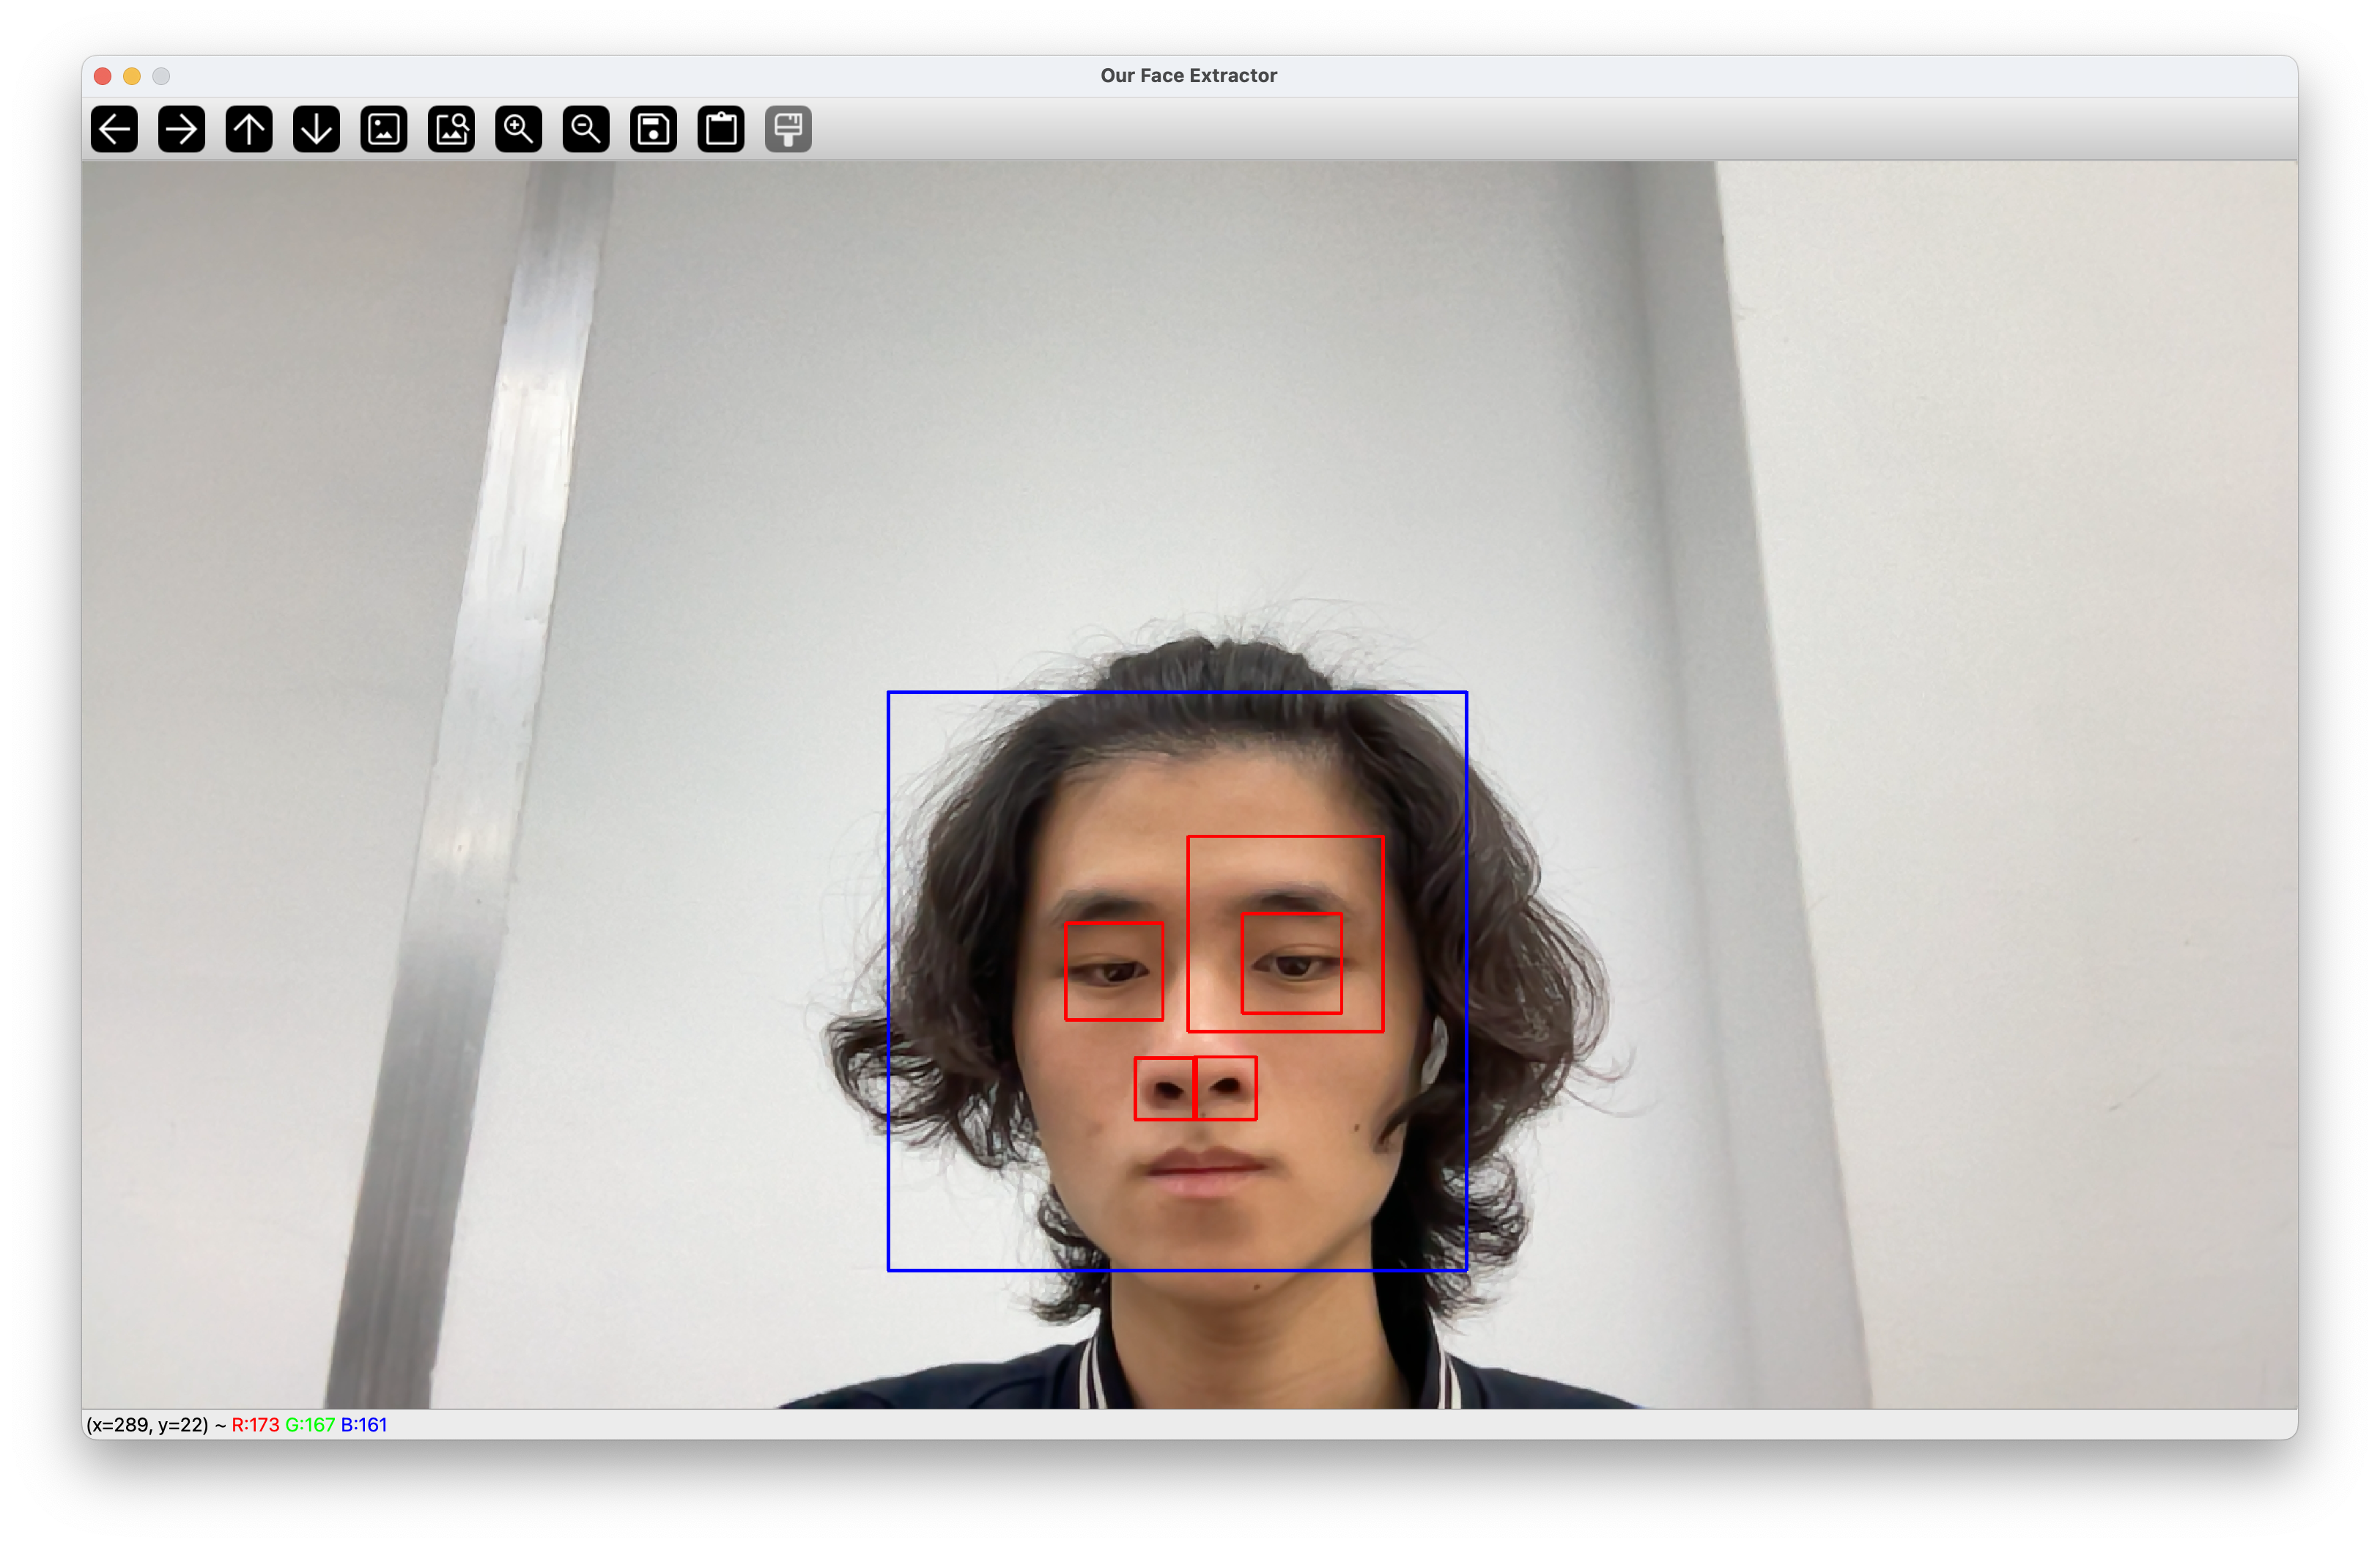